In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


In [3]:
DATA_PATH = Path("../data/interim/features_after_diagnoses.parquet")

df = pd.read_parquet(DATA_PATH)

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 130960
Columns: 40


,op_id,subject_id,age,sex,height,weight,race,asa,department,antype,...,potassium,albumin,inr,diabetes,hypertension,ckd,stroke,heart_failure,copd,cancer
0,484069807,178742874,30,F,155.0,50.0,Asian,NaN,OT,General,...,4.2,4.0,1.05,0,0,0,0,0,0,0
1,446270725,158995752,70,M,170.0,45.0,Asian,NaN,GS,General,...,5.0,3.9,1.00,1,0,0,0,0,0,1
2,406892271,108553242,50,F,165.0,70.0,Asian,NaN,OG,General,...,3.2,3.5,1.76,0,0,0,0,0,0,1
3,478413008,133278262,35,F,NaN,55.0,Asian,NaN,OG,Neuraxial,...,4.0,3.1,1.03,0,0,0,0,0,0,0
4,468516791,116924034,45,F,150.0,45.0,Asian,1.0,OG,General,...,4.2,4.0,0.90,0,0,0,0,0,0,0


In [5]:
df.columns.tolist()

['op_id',
 'subject_id',
 'age',
 'sex',
 'height',
 'weight',
 'race',
 'asa',
 'department',
 'antype',
 'emop',
 'icd10_pcs',
 'opstart_time',
 'icuin_time',
 'icuout_time',
 'discharge_time',
 'inhosp_death_time',
 'bmi',
 'heart_rate',
 'systolic_bp',
 'diastolic_bp',
 'respiratory_rate',
 'oxygen_saturation',
 'temperature',
 'hemoglobin',
 'wbc',
 'platelets',
 'creatinine',
 'glucose',
 'sodium',
 'potassium',
 'albumin',
 'inr',
 'diabetes',
 'hypertension',
 'ckd',
 'stroke',
 'heart_failure',
 'copd',
 'cancer']

In [6]:
target_time_columns = [
    "opstart_time",
    "icuin_time",
    "icuout_time",
    "discharge_time",
    "inhosp_death_time",
]

df[target_time_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130960 entries, 0 to 130959
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   opstart_time       130948 non-null  float64
 1   icuin_time         19195 non-null   float64
 2   icuout_time        18983 non-null   float64
 3   discharge_time     130960 non-null  int64  
 4   inhosp_death_time  1555 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 5.0 MB


In [7]:
df["icu_admission"] = (
    df["icuin_time"]
    .notna()
    .astype(int)
)

In [8]:
df["icu_admission"].value_counts()

icu_admission
0    111765
1     19195
Name: count, dtype: int64

In [9]:
df["icu_admission"].value_counts(normalize=True)

icu_admission
0    0.853429
1    0.146571
Name: proportion, dtype: float64

In [10]:
df["mortality"] = (
    df["inhosp_death_time"]
    .notna()
    .astype(int)
)

In [11]:
df["mortality"].value_counts()

mortality
0    129405
1      1555
Name: count, dtype: int64

In [12]:
df["mortality"].value_counts(normalize=True)

mortality
0    0.988126
1    0.011874
Name: proportion, dtype: float64

In [13]:
df["recovery_time"] = (
    df["discharge_time"] - df["opstart_time"]
)

In [14]:
df = df[
    df["recovery_time"].notna()
]

df = df[
    df["recovery_time"] >= 0
]

In [15]:
df["recovery_time"].describe()

count    1.309470e+05
mean     1.025747e+04
std      4.151219e+04
min      9.000000e+01
25%      2.320000e+03
50%      5.240000e+03
75%      1.058000e+04
max      5.369270e+06
Name: recovery_time, dtype: float64

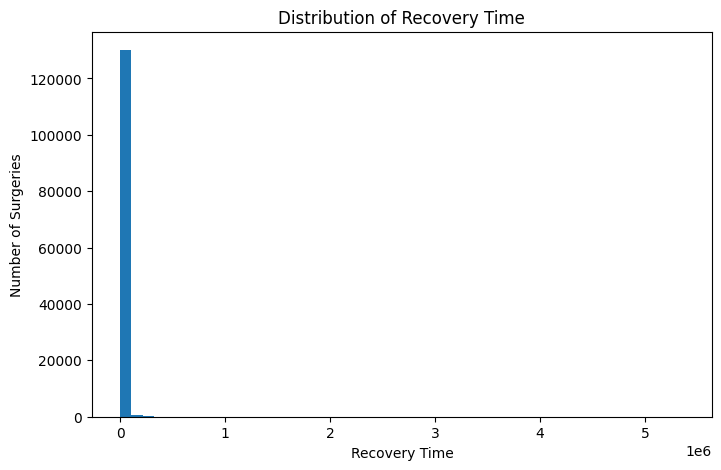

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["recovery_time"], bins=50)

plt.title("Distribution of Recovery Time")
plt.xlabel("Recovery Time")
plt.ylabel("Number of Surgeries")

plt.show()

In [17]:
df["recovery_time"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999]
)

count    1.309470e+05
mean     1.025747e+04
std      4.151219e+04
min      9.000000e+01
50%      5.240000e+03
90%      1.869700e+04
95%      2.951850e+04
99%      8.734890e+04
99.5%    1.275908e+05
99.9%    3.084501e+05
max      5.369270e+06
Name: recovery_time, dtype: float64

In [18]:
df.nlargest(20, "recovery_time")[
    [
        "op_id",
        "opstart_time",
        "discharge_time",
        "recovery_time",
    ]
]

,op_id,opstart_time,discharge_time,recovery_time
9128,438837583,9125.0,5378395,5369270.0
9146,430026941,10135.0,5378395,5368260.0
9718,415695738,33970.0,5378395,5344425.0
73066,439194078,3420.0,2835355,2831935.0
76003,411493596,127360.0,2835355,2707995.0
79520,413665093,275585.0,2835355,2559770.0
17650,498025367,523295.0,2979355,2456060.0
17676,419334605,525160.0,2979355,2454195.0
18234,479547296,546495.0,2979355,2432860.0
18887,444808284,571055.0,2979355,2408300.0


In [19]:
df[
    [
        "opstart_time",
        "discharge_time",
        "recovery_time",
    ]
].sample(10, random_state=42)

,opstart_time,discharge_time,recovery_time
107755,7700.0,25915,18215.0
72770,5335.0,15835,10500.0
52068,2390.0,10075,7685.0
75031,1935.0,4315,2380.0
84354,1925.0,2875,950.0
53053,1345.0,5755,4410.0
92511,2610.0,4315,1705.0
17601,2360.0,4315,1955.0
120473,798775.0,800635,1860.0
88899,2370.0,10075,7705.0


In [20]:
MAX_RECOVERY_MINUTES = 90 * 24 * 60

(
    df["recovery_time"] > MAX_RECOVERY_MINUTES
).sum()

np.int64(632)

In [21]:
(
    df["recovery_time"] > MAX_RECOVERY_MINUTES
).mean()

np.float64(0.0048263801385293285)

In [ ]:
MAX_RECOVERY_MINUTES = 90 * 24 * 60        #target cleaning - removing outliers

df = df[
    df["recovery_time"] <= MAX_RECOVERY_MINUTES
]

In [23]:
df["recovery_days"] = (
    df["recovery_time"] / 60 / 24
)

In [24]:
DROP_COLUMNS = [
    # IDs
    "op_id",
    "subject_id",

    # Target timestamps
    "opstart_time",
    "icuin_time",
    "icuout_time",
    "discharge_time",
    "inhosp_death_time",

    # Targets
    "icu_admission",
    "mortality",
    "recovery_time",
]

In [25]:
X = df.drop(columns=DROP_COLUMNS)

In [26]:
X.head()

,age,sex,height,weight,race,asa,department,antype,emop,icd10_pcs,...,albumin,inr,diabetes,hypertension,ckd,stroke,heart_failure,copd,cancer,recovery_days
0,30,F,155.0,50.0,Asian,NaN,OT,General,1,09B70,...,4.0,1.05,0,0,0,0,0,0,0,4.204861
1,70,M,170.0,45.0,Asian,NaN,GS,General,1,0WJG0,...,3.9,1.00,1,0,0,0,0,0,1,48.045139
2,50,F,165.0,70.0,Asian,NaN,OG,General,1,0DHS0,...,3.5,1.76,0,0,0,0,0,0,1,80.802083
3,35,F,NaN,55.0,Asian,NaN,OG,Neuraxial,1,10D00,...,3.1,1.03,0,0,0,0,0,0,0,3.836806
4,45,F,150.0,45.0,Asian,1.0,OG,General,0,0JQC0,...,4.0,0.90,0,0,0,0,0,0,0,5.517361


In [27]:
y_icu = df["icu_admission"]

y_mortality = df["mortality"]

y_recovery = df["recovery_days"]

In [28]:
print("Features:", X.shape)

print("ICU:", y_icu.shape)

print("Mortality:", y_mortality.shape)

print("Recovery:", y_recovery.shape)

Features: (130315, 34)
ICU: (130315,)
Mortality: (130315,)
Recovery: (130315,)


In [29]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

In [30]:
print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['sex', 'race', 'department', 'antype', 'icd10_pcs']

Numerical Features
['age', 'height', 'weight', 'asa', 'emop', 'bmi', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'respiratory_rate', 'oxygen_saturation', 'temperature', 'hemoglobin', 'wbc', 'platelets', 'creatinine', 'glucose', 'sodium', 'potassium', 'albumin', 'inr', 'diabetes', 'hypertension', 'ckd', 'stroke', 'heart_failure', 'copd', 'cancer', 'recovery_days']


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [35]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ]
)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

In [37]:
icu_balance = (
    y_icu
    .value_counts()
    .rename_axis("icu_admission")
    .reset_index(name="count")
)

icu_balance["percentage"] = (
    icu_balance["count"] / len(y_icu) * 100
)

icu_balance

,icu_admission,count,percentage
0,0,111563,85.610252
1,1,18752,14.389748


In [38]:
X_train_icu, X_test_icu, y_train_icu, y_test_icu = train_test_split(
    X,
    y_icu,
    test_size=0.20,
    random_state=42,
    stratify=y_icu,
)

In [39]:
print("Training features:", X_train_icu.shape)
print("Testing features:", X_test_icu.shape)

print("\nTraining target distribution:")
print(y_train_icu.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test_icu.value_counts(normalize=True))

Training features: (104252, 34)
Testing features: (26063, 34)

Training target distribution:
icu_admission
0    0.856099
1    0.143901
Name: proportion, dtype: float64

Testing target distribution:
icu_admission
0    0.856118
1    0.143882
Name: proportion, dtype: float64


In [40]:
from sklearn.linear_model import LogisticRegression

icu_baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

In [41]:
icu_baseline_pipeline.fit(
    X_train_icu,
    y_train_icu,
)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [42]:
numeric_check = X[numerical_features].replace(
    [np.inf, -np.inf],
    np.nan
)

infinite_counts = pd.Series({
    column: np.isinf(X[column]).sum()
    for column in numerical_features
})

infinite_counts[infinite_counts > 0]

bmi    3
dtype: int64

In [43]:
X[numerical_features].max().sort_values(ascending=False).head(15)

bmi                           inf
height               1.793500e+04
platelets            4.700000e+02
weight               4.550000e+02
glucose              3.020000e+02
systolic_bp          1.780000e+02
sodium               1.470000e+02
heart_rate           1.080000e+02
oxygen_saturation    1.000000e+02
diastolic_bp         9.800000e+01
age                  9.000000e+01
recovery_days        8.980208e+01
temperature          3.700000e+01
respiratory_rate     2.000000e+01
wbc                  1.944000e+01
dtype: float64

In [44]:
X = X.replace([np.inf, -np.inf], np.nan)

In [48]:
X.loc[
    (X["bmi"] < 10) | (X["bmi"] > 80),
    "bmi"
] = np.nan

In [49]:
X.loc[
    (X["height"] <= 0) | (X["height"] > 250),
    "height"
] = np.nan

X.loc[
    (X["weight"] <= 0) | (X["weight"] > 400),
    "weight"
] = np.nan

In [50]:
print(
    "Infinite numeric values:",
    np.isinf(
        X[numerical_features].to_numpy(dtype=float)
    ).sum()
)

Infinite numeric values: 0


In [51]:
X_train_icu, X_test_icu, y_train_icu, y_test_icu = train_test_split(
    X,
    y_icu,
    test_size=0.20,
    random_state=42,
    stratify=y_icu,
)

In [52]:
icu_baseline_pipeline.fit(
    X_train_icu,
    y_train_icu,
)

c:\Users\Shivani12\Downloads\Masters\NYU\Projects\inspire-surgical-copilot\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("=" * 50)
print("ICU Admission Model Evaluation")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test_icu, icu_predictions):.4f}")
print(f"Precision: {precision_score(y_test_icu, icu_predictions):.4f}")
print(f"Recall   : {recall_score(y_test_icu, icu_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test_icu, icu_predictions):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test_icu, icu_probabilities):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test_icu, icu_predictions))

print("\nClassification Report")
print(classification_report(y_test_icu, icu_predictions))

ICU Admission Model Evaluation


NameError: name 'icu_predictions' is not defined

In [56]:
type(icu_predictions)

NameError: name 'icu_predictions' is not defined

In [57]:
icu_predictions = icu_baseline_pipeline.predict(X_test_icu)

icu_probabilities = icu_baseline_pipeline.predict_proba(
    X_test_icu
)[:, 1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("=" * 50)
print("ICU Admission Model Evaluation")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test_icu, icu_predictions):.4f}")
print(f"Precision: {precision_score(y_test_icu, icu_predictions):.4f}")
print(f"Recall   : {recall_score(y_test_icu, icu_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test_icu, icu_predictions):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test_icu, icu_probabilities):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test_icu, icu_predictions))

print("\nClassification Report")
print(classification_report(y_test_icu, icu_predictions))

ICU Admission Model Evaluation
Accuracy : 0.8358
Precision: 0.4580
Recall   : 0.7685
F1 Score : 0.5739
ROC AUC  : 0.8849

Confusion Matrix
[[18902  3411]
 [  868  2882]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.85      0.90     22313
           1       0.46      0.77      0.57      3750

    accuracy                           0.84     26063
   macro avg       0.71      0.81      0.74     26063
weighted avg       0.88      0.84      0.85     26063



In [59]:
from xgboost import XGBClassifier

In [60]:
negative_count = (y_train_icu == 0).sum()
positive_count = (y_train_icu == 1).sum()

icu_scale_pos_weight = negative_count / positive_count

print(f"Negative cases: {negative_count}")
print(f"Positive cases: {positive_count}")
print(f"Scale pos weight: {icu_scale_pos_weight:.2f}")

Negative cases: 89250
Positive cases: 15002
Scale pos weight: 5.95


In [61]:
icu_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=icu_scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [62]:
icu_xgb_pipeline.fit(
    X_train_icu,
    y_train_icu,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
icu_xgb_predictions = icu_xgb_pipeline.predict(X_test_icu)

icu_xgb_probabilities = icu_xgb_pipeline.predict_proba(
    X_test_icu
)[:, 1]

In [65]:
print("=" * 50)
print("ICU Admission XGBoost Evaluation")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"ROC AUC  : "
    f"{roc_auc_score(y_test_icu, icu_xgb_probabilities):.4f}"
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test_icu,
        icu_xgb_predictions,
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_test_icu,
        icu_xgb_predictions,
    )
)

ICU Admission XGBoost Evaluation
Accuracy : 0.8610
Precision: 0.5110
Recall   : 0.7880
F1 Score : 0.6200
ROC AUC  : 0.9117

Confusion Matrix
[[19485  2828]
 [  795  2955]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     22313
           1       0.51      0.79      0.62      3750

    accuracy                           0.86     26063
   macro avg       0.74      0.83      0.77     26063
weighted avg       0.90      0.86      0.87     26063



In [66]:
icu_model_comparison = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "XGBoost",
        ],
        "Accuracy": [
            accuracy_score(y_test_icu, icu_predictions),
            accuracy_score(y_test_icu, icu_xgb_predictions),
        ],
        "Precision": [
            precision_score(y_test_icu, icu_predictions),
            precision_score(y_test_icu, icu_xgb_predictions),
        ],
        "Recall": [
            recall_score(y_test_icu, icu_predictions),
            recall_score(y_test_icu, icu_xgb_predictions),
        ],
        "F1": [
            f1_score(y_test_icu, icu_predictions),
            f1_score(y_test_icu, icu_xgb_predictions),
        ],
        "ROC_AUC": [
            roc_auc_score(y_test_icu, icu_probabilities),
            roc_auc_score(y_test_icu, icu_xgb_probabilities),
        ],
    }
)

icu_model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.835821,0.457969,0.768533,0.573932,0.884855
1,XGBoost,0.860991,0.510980,0.788000,0.619952,0.911669


In [67]:
mortality_balance = (
    y_mortality
    .value_counts()
    .rename_axis("mortality")
    .reset_index(name="count")
)

mortality_balance["percentage"] = (
    mortality_balance["count"] / len(y_mortality) * 100
)

mortality_balance

,mortality,count,percentage
0,0,128855,98.879638
1,1,1460,1.120362


In [70]:
X_train_mortality, X_test_mortality, y_train_mortality, y_test_mortality = train_test_split(
    X,
    y_mortality,
    test_size=0.20,
    random_state=42,
    stratify=y_mortality,
)

In [72]:
negative_count = (y_train_mortality == 0).sum()
positive_count = (y_train_mortality == 1).sum()

mortality_scale_pos_weight = negative_count / positive_count

print(f"Negative cases: {negative_count}")
print(f"Positive cases: {positive_count}")
print(f"Scale Pos Weight: {mortality_scale_pos_weight:.2f}")

Negative cases: 103084
Positive cases: 1168
Scale Pos Weight: 88.26


In [73]:
mortality_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=mortality_scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [74]:
mortality_xgb_pipeline.fit(
    X_train_mortality,
    y_train_mortality,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
mortality_predictions = mortality_xgb_pipeline.predict(
    X_test_mortality
)

mortality_probabilities = mortality_xgb_pipeline.predict_proba(
    X_test_mortality
)[:, 1]

In [76]:
print("=" * 50)
print("Mortality XGBoost Evaluation")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test_mortality, mortality_predictions):.4f}")
print(f"Precision: {precision_score(y_test_mortality, mortality_predictions):.4f}")
print(f"Recall   : {recall_score(y_test_mortality, mortality_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test_mortality, mortality_predictions):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test_mortality, mortality_probabilities):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test_mortality, mortality_predictions))

print("\nClassification Report")
print(classification_report(y_test_mortality, mortality_predictions))

Mortality XGBoost Evaluation
Accuracy : 0.9382
Precision: 0.1163
Recall   : 0.6849
F1 Score : 0.1989
ROC AUC  : 0.9163

Confusion Matrix
[[24252  1519]
 [   92   200]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     25771
           1       0.12      0.68      0.20       292

    accuracy                           0.94     26063
   macro avg       0.56      0.81      0.58     26063
weighted avg       0.99      0.94      0.96     26063



In [77]:
y_recovery = df["recovery_days"]

In [78]:
MAX_RECOVERY_DAYS = 90

recovery_mask = (
    df["recovery_days"].notna()
    & (df["recovery_days"] >= 0)
    & (df["recovery_days"] <= MAX_RECOVERY_DAYS)
)

X_recovery = X.loc[recovery_mask].copy()
y_recovery_clean = df.loc[recovery_mask, "recovery_days"].copy()

print("Recovery model rows:", len(X_recovery))
print(y_recovery_clean.describe())

Recovery model rows: 130315
count    130315.000000
mean          6.115799
std           8.582681
min           0.062500
25%           1.607639
50%           3.635417
75%           7.295139
max          89.802083
Name: recovery_days, dtype: float64


In [79]:
X_train_recovery, X_test_recovery, y_train_recovery, y_test_recovery = (
    train_test_split(
        X_recovery,
        y_recovery_clean,
        test_size=0.20,
        random_state=42,
    )
)

In [ ]:
print("Training rows:", X_train_recovery.shape)
print("Testing rows:", X_test_recovery.shape)

Training rows: (104252, 34)
Testing rows: (26063, 34)


In [81]:
from xgboost import XGBRegressor
recovery_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [82]:
recovery_xgb_pipeline.fit(
    X_train_recovery,
    y_train_recovery,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
recovery_predictions = recovery_xgb_pipeline.predict(
    X_test_recovery
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

recovery_mae = mean_absolute_error(
    y_test_recovery,
    recovery_predictions,
)

recovery_rmse = np.sqrt(
    mean_squared_error(
        y_test_recovery,
        recovery_predictions,
    )
)

recovery_r2 = r2_score(
    y_test_recovery,
    recovery_predictions,
)

print("=" * 50)
print("Recovery Time XGBoost Evaluation")
print("=" * 50)

print(f"MAE : {recovery_mae:.4f} days")
print(f"RMSE: {recovery_rmse:.4f} days")
print(f"R²  : {recovery_r2:.4f}")


Recovery Time XGBoost Evaluation
MAE : 0.1558 days
RMSE: 0.6169 days
R²  : 0.9949


In [85]:
recovery_comparison = pd.DataFrame(
    {
        "Actual Recovery Days": y_test_recovery,
        "Predicted Recovery Days": recovery_predictions,
    }
)

recovery_comparison["Absolute Error"] = (
    recovery_comparison["Actual Recovery Days"]
    - recovery_comparison["Predicted Recovery Days"]
).abs()

recovery_comparison.sample(
    20,
    random_state=42,
).round(2)

,Actual Recovery Days,Predicted Recovery Days,Absolute Error
7502,3.37,3.330000,0.04
126925,2.65,2.520000,0.13
105632,4.61,4.350000,0.27
33706,1.64,1.610000,0.03
16928,0.51,0.520000,0.02
17613,5.60,5.570000,0.03
21927,0.63,0.630000,0.01
84399,4.27,4.090000,0.19
38486,5.42,5.420000,0.01
36920,2.34,2.270000,0.07


In [86]:
recovery_comparison = pd.DataFrame(
    {
        "Actual Recovery Days": y_test_recovery,
        "Predicted Recovery Days": recovery_predictions,
    }
)

recovery_comparison["Absolute Error"] = (
    recovery_comparison["Actual Recovery Days"]
    - recovery_comparison["Predicted Recovery Days"]
).abs()

recovery_comparison.sample(
    20,
    random_state=42,
).round(2)

,Actual Recovery Days,Predicted Recovery Days,Absolute Error
7502,3.37,3.330000,0.04
126925,2.65,2.520000,0.13
105632,4.61,4.350000,0.27
33706,1.64,1.610000,0.03
16928,0.51,0.520000,0.02
17613,5.60,5.570000,0.03
21927,0.63,0.630000,0.01
84399,4.27,4.090000,0.19
38486,5.42,5.420000,0.01
36920,2.34,2.270000,0.07


In [87]:
recovery_evaluation = pd.DataFrame(
    {
        "actual": y_test_recovery,
        "predicted": recovery_predictions,
    }
)

recovery_evaluation["duration_group"] = pd.cut(
    recovery_evaluation["actual"],
    bins=[0, 1, 3, 7, 14, 30, 90],
    labels=[
        "<1 day",
        "1–3 days",
        "3–7 days",
        "7–14 days",
        "14–30 days",
        "30–90 days",
    ],
    include_lowest=True,
)

recovery_error_by_group = (
    recovery_evaluation
    .groupby("duration_group", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "cases": len(group),
                "MAE": mean_absolute_error(
                    group["actual"],
                    group["predicted"],
                ),
            }
        )
    )
)

recovery_error_by_group

C:\Users\Shivani12\AppData\Local\Temp\ipykernel_30588\910762552.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,cases,MAE
duration_group,,
<1 day,2717.0,0.048497
1–3 days,8012.0,0.061125
3–7 days,8601.0,0.077846
7–14 days,4514.0,0.136096
14–30 days,1557.0,0.335677
30–90 days,662.0,2.466230


In [88]:
X.columns.tolist()

['age',
 'sex',
 'height',
 'weight',
 'race',
 'asa',
 'department',
 'antype',
 'emop',
 'icd10_pcs',
 'bmi',
 'heart_rate',
 'systolic_bp',
 'diastolic_bp',
 'respiratory_rate',
 'oxygen_saturation',
 'temperature',
 'hemoglobin',
 'wbc',
 'platelets',
 'creatinine',
 'glucose',
 'sodium',
 'potassium',
 'albumin',
 'inr',
 'diabetes',
 'hypertension',
 'ckd',
 'stroke',
 'heart_failure',
 'copd',
 'cancer',
 'recovery_days']

In [89]:
recovery_comparison.sample(20, random_state=42).round(2)

,Actual Recovery Days,Predicted Recovery Days,Absolute Error
7502,3.37,3.330000,0.04
126925,2.65,2.520000,0.13
105632,4.61,4.350000,0.27
33706,1.64,1.610000,0.03
16928,0.51,0.520000,0.02
17613,5.60,5.570000,0.03
21927,0.63,0.630000,0.01
84399,4.27,4.090000,0.19
38486,5.42,5.420000,0.01
36920,2.34,2.270000,0.07


In [98]:
FEATURE_LABELS = {
    "age": "Age",
    "sex": "Sex",
    "height": "Height",
    "weight": "Weight",
    "bmi": "BMI",
    "race": "Race",
    "asa": "ASA Physical Status",
    "department": "Surgical Department",
    "antype": "Anesthesia Type",
    "emop": "Emergency Surgery",
    "icd10_pcs": "Surgical Procedure",
    "heart_rate": "Heart Rate",
    "systolic_bp": "Systolic Blood Pressure",
    "diastolic_bp": "Diastolic Blood Pressure",
    "respiratory_rate": "Respiratory Rate",
    "oxygen_saturation": "Oxygen Saturation",
    "temperature": "Temperature",
    "hemoglobin": "Hemoglobin",
    "wbc": "White Blood Cell Count",
    "platelets": "Platelet Count",
    "creatinine": "Creatinine",
    "glucose": "Glucose",
    "sodium": "Sodium",
    "potassium": "Potassium",
    "albumin": "Albumin",
    "inr": "INR",
    "diabetes": "Diabetes",
    "hypertension": "Hypertension",
    "ckd": "Chronic Kidney Disease",
    "stroke": "History of Stroke",
    "heart_failure": "Heart Failure",
    "copd": "COPD",
    "cancer": "Cancer",
}

In [91]:
def get_transformed_feature_sources(fitted_preprocessor):
    """
    Return the original feature corresponding to each transformed column.
    """

    feature_sources = []

    # Numerical features remain one column each.
    feature_sources.extend(numerical_features)

    # Categorical features expand into one column per category.
    categorical_transformer = (
        fitted_preprocessor
        .named_transformers_["categorical"]
    )

    encoder = categorical_transformer.named_steps["encoder"]

    for feature, categories in zip(
        categorical_features,
        encoder.categories_,
    ):
        feature_sources.extend(
            [feature] * len(categories)
        )

    return feature_sources


In [95]:
from xgboost import DMatrix

def explain_prediction(
    pipeline,
    patient_row,
    top_n,
    prediction_type,
):
    """
    Explain one XGBoost prediction using XGBoost's
    built-in SHAP contribution calculation.
    """

    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    fitted_model = pipeline.named_steps["model"]

    # Apply the exact preprocessing used during training.
    transformed_patient = fitted_preprocessor.transform(
        patient_row
    )

    # XGBoost can accept the transformed sparse matrix directly.
    transformed_dmatrix = DMatrix(transformed_patient)

    # Get SHAP-style feature contributions.
    contributions = fitted_model.get_booster().predict(
        transformed_dmatrix,
        pred_contribs=True,
    )

    # The final value is the bias/base value, not a feature.
    patient_contributions = contributions[0, :-1]

    feature_sources = get_transformed_feature_sources(
        fitted_preprocessor
    )

    if len(feature_sources) != len(patient_contributions):
        raise ValueError(
            f"Feature mismatch: {len(feature_sources)} feature names "
            f"but {len(patient_contributions)} contributions."
        )

    explanation = pd.DataFrame(
        {
            "feature": feature_sources,
            "shap_value": patient_contributions,
        }
    )

    # Combine one-hot encoded columns back into their original feature.
    explanation = (
        explanation
        .groupby("feature", as_index=False)["shap_value"]
        .sum()
    )

    explanation["importance"] = (
        explanation["shap_value"].abs()
    )

    explanation = (
        explanation
        .sort_values(
            "importance",
            ascending=False,
        )
        .head(top_n)
        .copy()
    )

    explanation["label"] = (
        explanation["feature"]
        .map(FEATURE_LABELS)
        .fillna(explanation["feature"])
    )

    if prediction_type == "mortality":
        explanation["direction"] = np.where(
            explanation["shap_value"] > 0,
            "increased estimated mortality risk",
            "reduced estimated mortality risk",
        )

    elif prediction_type == "recovery":
        explanation["direction"] = np.where(
            explanation["shap_value"] > 0,
            "longer estimated recovery",
            "shorter estimated recovery",
        )

    else:
        raise ValueError(
            "prediction_type must be 'mortality' or 'recovery'."
        )

    return explanation[
        [
            "feature",
            "label",
            "shap_value",
            "direction",
        ]
    ].reset_index(drop=True)

In [93]:
sample_index = X_test_mortality.index[0]

sample_patient = X.loc[[sample_index]]

sample_patient

,age,sex,height,weight,race,asa,department,antype,emop,icd10_pcs,...,albumin,inr,diabetes,hypertension,ckd,stroke,heart_failure,copd,cancer,recovery_days
52678,75,F,150.0,60.0,Asian,2.0,OT,MAC,0,08DJ3,...,4.1,0.95,1,0,0,1,0,0,0,0.645833


In [99]:
mortality_top_factor = explain_prediction(
    pipeline=mortality_xgb_pipeline,
    patient_row=sample_patient,
    top_n=1,
    prediction_type="mortality",
)

mortality_top_factor

XGBoostError: [02:27:14] C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api_utils.h:129: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (2147 vs. 2144) : 

In [100]:
from sklearn.base import clone
mortality_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=mortality_scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [102]:
mortality_xgb_pipeline.fit(
    X_train_mortality,
    y_train_mortality,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [103]:
mortality_predictions = mortality_xgb_pipeline.predict(
    X_test_mortality
)

mortality_probabilities = mortality_xgb_pipeline.predict_proba(
    X_test_mortality
)[:, 1]

In [104]:
recovery_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [105]:
recovery_xgb_pipeline.fit(
    X_train_recovery,
    y_train_recovery,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
mortality_preprocessor = (
    mortality_xgb_pipeline.named_steps["preprocessor"]
)

mortality_model = (
    mortality_xgb_pipeline.named_steps["model"]
)

sample_transformed = mortality_preprocessor.transform(
    sample_patient
)

print("Preprocessor output:", sample_transformed.shape[1])
print("Model input features:", mortality_model.n_features_in_)

Preprocessor output: 2143
Model input features: 2143


In [107]:
mortality_top_factor = explain_prediction(
    pipeline=mortality_xgb_pipeline,
    patient_row=sample_patient,
    top_n=1,
    prediction_type="mortality",
)

mortality_top_factor

,feature,label,shap_value,direction
0,recovery_days,recovery_days,-0.97767,reduced estimated mortality risk


In [108]:
mortality_top_factor = explain_prediction(
    pipeline=mortality_xgb_pipeline,
    patient_row=sample_patient,
    top_n=1,
    prediction_type="mortality",
)

mortality_top_factor

,feature,label,shap_value,direction
0,recovery_days,recovery_days,-0.97767,reduced estimated mortality risk


In [109]:
sample_mortality_probability = mortality_xgb_pipeline.predict_proba(
    sample_patient
)[0, 1]

sample_recovery_prediction = max(
    float(
        recovery_xgb_pipeline.predict(
            recovery_sample_patient
        )[0]
    ),
    0,
)

print("=" * 50)
print("Mortality Prediction")
print("=" * 50)
print(f"Mortality risk: {sample_mortality_probability:.2%}")
print(
    f"Strongest factor: "
    f"{mortality_top_factor.loc[0, 'label']}"
)
print(
    f"Effect: "
    f"{mortality_top_factor.loc[0, 'direction']}"
)

print("\n" + "=" * 50)
print("Recovery Prediction")
print("=" * 50)
print(
    f"Expected recovery time: "
    f"{sample_recovery_prediction:.2f} days"
)

print("\nMain contributing factors:")

for _, factor in recovery_top_factors.iterrows():
    print(
        f"- {factor['label']}: "
        f"{factor['direction']}"
    )

NameError: name 'recovery_sample_patient' is not defined

In [110]:
recovery_sample_patient

NameError: name 'recovery_sample_patient' is not defined

In [111]:
recovery_sample_index = X_test_recovery.index[0]

recovery_sample_index

np.int64(22633)

In [113]:
recovery_sample_patient = X_recovery.loc[
    [recovery_sample_index]
]

recovery_sample_patient

,age,sex,height,weight,race,asa,department,antype,emop,icd10_pcs,...,albumin,inr,diabetes,hypertension,ckd,stroke,heart_failure,copd,cancer,recovery_days
22633,45,F,155.0,45.0,Asian,2.0,OG,General,0,07B00,...,4.4,0.95,0,0,0,0,0,0,1,2.3125


In [114]:
recovery_top_factors = explain_prediction(
    pipeline=recovery_xgb_pipeline,
    patient_row=recovery_sample_patient,
    top_n=3,
    prediction_type="recovery",
)

In [115]:
sample_mortality_probability = mortality_xgb_pipeline.predict_proba(
    sample_patient
)[0, 1]

sample_recovery_prediction = max(
    float(
        recovery_xgb_pipeline.predict(
            recovery_sample_patient
        )[0]
    ),
    0,
)

print("=" * 50)
print("Mortality Prediction")
print("=" * 50)
print(f"Mortality risk: {sample_mortality_probability:.2%}")
print(
    f"Strongest factor: "
    f"{mortality_top_factor.loc[0, 'label']}"
)
print(
    f"Effect: "
    f"{mortality_top_factor.loc[0, 'direction']}"
)

print("\n" + "=" * 50)
print("Recovery Prediction")
print("=" * 50)
print(
    f"Expected recovery time: "
    f"{sample_recovery_prediction:.2f} days"
)

print("\nMain contributing factors:")

for _, factor in recovery_top_factors.iterrows():
    print(
        f"- {factor['label']}: "
        f"{factor['direction']}"
    )

Mortality Prediction
Mortality risk: 1.16%
Strongest factor: recovery_days
Effect: reduced estimated mortality risk

Recovery Prediction
Expected recovery time: 2.34 days

Main contributing factors:
- recovery_days: shorter estimated recovery
- Albumin: shorter estimated recovery
- Surgical Department: longer estimated recovery


In [116]:
from pathlib import Path
import joblib

In [117]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [118]:
joblib.dump(
    icu_xgb_pipeline,
    MODEL_DIR / "icu_xgb_predictions.joblib",
)

joblib.dump(
    mortality_xgb_pipeline,
    MODEL_DIR / "mortality_xgb_pipeline.joblib",
)

joblib.dump(
    recovery_xgb_pipeline,
    MODEL_DIR / "recovery_xgb_pipeline.joblib",
)

['..\\models\\recovery_xgb_pipeline.joblib']

In [119]:
joblib.dump(
    X.columns.tolist(),
    MODEL_DIR / "input_features.joblib",
)



['..\\models\\input_features.joblib']

In [120]:
loaded_icu = joblib.load(
    MODEL_DIR / "icu_xgb_predictions.joblib"
)

loaded_icu.predict_proba(
    X_test_icu.iloc[[0]]
)

ValueError: Feature shape mismatch, expected: 2170, got 2146

In [121]:
from sklearn.base import clone

icu_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=icu_scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [122]:
icu_xgb_pipeline.fit(
    X_train_icu,
    y_train_icu,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [123]:
icu_xgb_predictions = icu_xgb_pipeline.predict(
    X_test_icu
)

icu_xgb_probabilities = icu_xgb_pipeline.predict_proba(
    X_test_icu
)[:, 1]

In [124]:
icu_preprocessor = (
    icu_xgb_pipeline.named_steps["preprocessor"]
)

icu_model = (
    icu_xgb_pipeline.named_steps["model"]
)

icu_sample_transformed = icu_preprocessor.transform(
    X_test_icu.iloc[[0]]
)

print(
    "Preprocessor output:",
    icu_sample_transformed.shape[1],
)

print(
    "Model input features:",
    icu_model.n_features_in_,
)

Preprocessor output: 2170
Model input features: 2170


In [125]:
print("=" * 50)
print("ICU Admission XGBoost Evaluation")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_icu, icu_xgb_predictions):.4f}"
)

print(
    f"ROC AUC  : "
    f"{roc_auc_score(y_test_icu, icu_xgb_probabilities):.4f}"
)

ICU Admission XGBoost Evaluation
Accuracy : 0.8610
Precision: 0.5110
Recall   : 0.7880
F1 Score : 0.6200
ROC AUC  : 0.9117


In [126]:
joblib.dump(
    icu_xgb_pipeline,
    MODEL_DIR / "icu_xgb_pipeline.joblib",
)

['..\\models\\icu_xgb_pipeline.joblib']

In [127]:
joblib.dump(
    icu_xgb_pipeline,
    MODEL_DIR / "icu_xgb_pipeline.joblib",
)

['..\\models\\icu_xgb_pipeline.joblib']